<a href="https://colab.research.google.com/github/Symon-CNA/PPC-2/blob/main/PPC_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PPC 2**

**1.** Implemente o método de Bairstow para determinar as raízes de um polinômio de
grau arbitrário, incluindo o tratamento de raízes complexas conjugadas;
8

**2.** Valide o programa construindo um polinômio de sétima ordem com raízes previamente conhecidas (por exemplo, obtido a partir da multiplicação de seus monômios) e verificando se o método é capaz de recuperar essas raízes dentro de uma tolerância numérica adequada;

**3.** Analise a convergência do método para diferentes escolhas iniciais dos parâmetros r0 e s0, discutindo sua influência na estabilidade e na velocidade de convergência;

**4.** Utilize o programa desenvolvido para resolver o polinômio característico obtido na Atividade para Casa (APC2), determinando os autovalores do sistema dinâmico;

**5.** Interprete os resultados obtidos à luz do comportamento físico do sistema (estabilidade, amortecimento, frequência de oscilação);

**6.** Desenvolva uma rotina adicional que realize uma varredura sistemática dos valores iniciais r0 e s0 no plano bidimensional, registrando o comportamento de convergência
do método;

**7.** A partir dessa varredura, construa o fractal de Bairstow associado ao polinômio em estudo, identificando regiões de convergência e possíveis padrões estruturais no plano (r, s).

# **Requisitos de implementação:**

• O código deve ser implementado a partir dos conceitos desenvolvidos pelo aluno, não sendo permitido o uso de bibliotecas que realizem diretamente a integração numérica;

• É permitido o uso de estruturas básicas da linguagem, como vetores, matrizes,
funções, laços e condicionais;

• O código deve estar devidamente comentado e organizado;

• Os resultados devem ser apresentados de forma clara, incluindo gráficos e análises.

=== Validação com Polinómio de 7ª Ordem ===
Raízes Conhecidas de Teste: [-3.0, -1.0, 2.0, 4.0, -5.0, (1+2j), (1-2j)]
Raízes Calculadas pelo Método:
  λ = 2.00000 + 0.00000i
  λ = -1.00000 + 0.00000i
  λ = 4.00000 + 0.00000i
  λ = -3.00000 + 0.00000i
  λ = 1.00000 + 2.00000i
  λ = 1.00000 + -2.00000i
  λ = -5.00000 + 0.00000i

=== Resolução do Polinómio Característico da APC2 ===
Autovalores Obts (Raízes do Sistema Dinâmico):
  λ = -0.05314 + 0.55350i
     -> Frequência de Oscilação: 0.5535 rad/s
     -> Taxa de Amortecimento (ζ): 0.0956
  λ = -0.05314 + -0.55350i
     -> Frequência de Oscilação: 0.5535 rad/s
     -> Taxa de Amortecimento (ζ): 0.0956
  λ = -0.17186 + 1.79018i
     -> Frequência de Oscilação: 1.7902 rad/s
     -> Taxa de Amortecimento (ζ): 0.0956
  λ = -0.17186 + -1.79018i
     -> Frequência de Oscilação: 1.7902 rad/s
     -> Taxa de Amortecimento (ζ): 0.0956

=== Gerando o Fractal de Bairstow... ===
Gráfico do Fractal salvo com sucesso como 'bairstow_fractal_corrigido.p

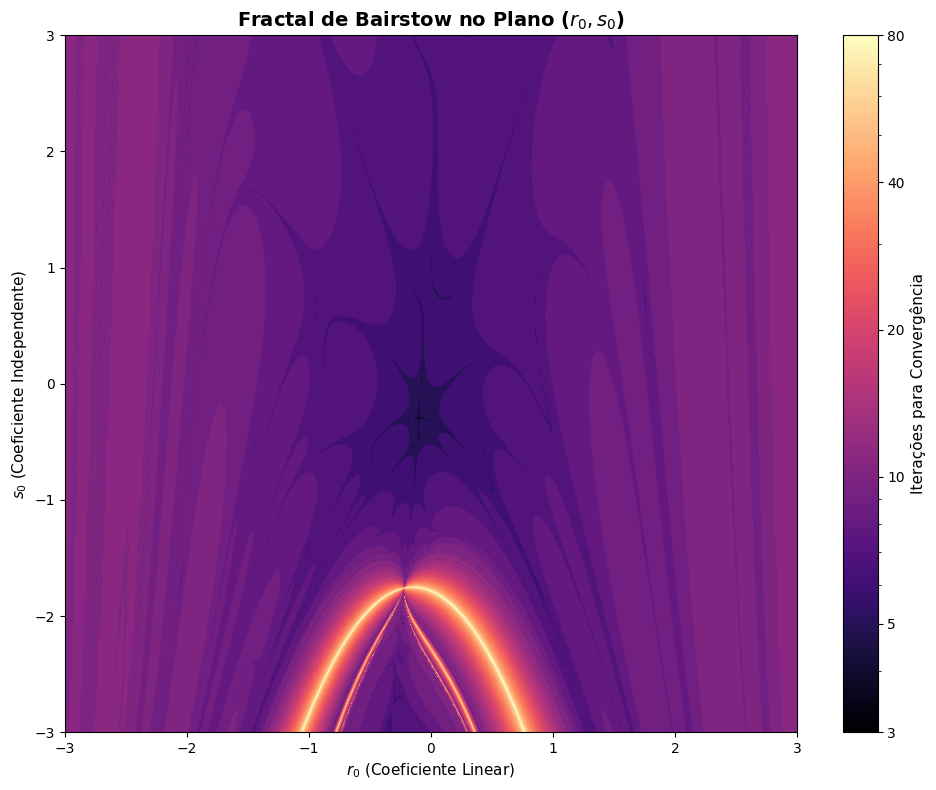

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

class BairstowSolver:

    def __init__(self, tol=1e-8, max_iter=100):
        """Inicializa os parâmetros de tolerância e limite de iterações do resolvedor."""
        self.tol = tol  # Tolerância para o critério de paragem (resto próximo de zero)
        self.max_iter = max_iter  # Número máximo de iterações por par de raízes

    def bairstow_step(self, a, r, s):
        """Executa um único passo do método de Newton-Raphson a duas variáveis

        para ajustar os coeficientes (r, s) do divisor quadrático D(x) = x^2 -
        r*x - s.
        """
        n = len(a) - 1  # Grau do polinómio atual
        b = [0.0] * (n + 1)  # Vetor para os coeficientes do polinómio quociente
        c = [0.0] * (n + 1)  # Vetor para as derivadas parciais (esquema sintético)

        # 1. Deflação Polinomial: Cálculo dos coeficientes 'b' (Resto e Quociente)
        b[n] = a[n]
        if n >= 1:
            b[n - 1] = a[n - 1] + r * b[n]
        for i in range(n - 2, -1, -1):
            b[i] = a[i] + r * b[i + 1] + s * b[i + 2]

        # 2. Divisão Sintética Secundária: Cálculo dos coeficientes 'c' (Derivadas Parciais)
        c[n] = b[n]
        if n >= 1:
            c[n - 1] = b[n - 1] + r * c[n]
        for i in range(n - 2, 1, -1):
            c[i] = b[i] + r * c[i + 1] + s * c[i + 2]

        # Mapeamento dos termos para o sistema linear 2x2 do Newton-Raphson
        c1 = c[1]
        c2 = c[2]
        c3 = c[3] if n >= 3 else 0.0

        # Cálculo do Determinante da Matriz Jacobiana
        det = c2 * c2 - c1 * c3

        # Se o determinante for muito próximo de zero, o método falha (divisão por zero)
        if abs(det) < 1e-12:
            return r, s, False, (b[0], b[1])

        # 3. Resolução do Sistema Linear 2x2 via Regra de Cramer para obter dr e ds
        dr = (-b[1] * c2 - (-b[0]) * c3) / det
        ds = (c2 * (-b[0]) - c1 * (-b[1])) / det

        # Retorna o par (r, s) atualizado, indicação de sucesso e os restos (b0, b1)
        return r + dr, s + ds, True, (b[0], b[1])

    def solve(self, a, r0=0.5, s0=0.5):
        """Encontra iterativamente todas as raízes do polinómio a_n*x^n + ... + a_0 = 0."""
        a_curr = list(a)
        roots = []  # Lista para armazenar as raízes encontradas

        # Processa o polinómio enquanto o seu grau for maior que 2
        while len(a_curr) - 1 > 2:
            n = len(a_curr) - 1
            r, s = r0, s0
            converged = False

            # Ciclo de Newton-Raphson para encontrar um par (r, s) que anule o resto
            for _ in range(self.max_iter):
                r_new, s_new, ok, residues = self.bairstow_step(a_curr, r, s)
                if not ok:
                    break

                # Verifica se o resto (b0 e b1) está dentro da tolerância exigida
                if abs(residues[0]) < self.tol and abs(residues[1]) < self.tol:
                    r, s = r_new, s_new
                    converged = True
                    break
                r, s = r_new, s_new

            # Se não convergir com o palpite inicial, faz uma pequena perturbação
            if not converged:
                r, s = r0 + 0.1, s0 - 0.1

            # Aplica a fórmula quadrática no fator x^2 - r*x - s = 0 para extrair 2 raízes
            disc = r**2 + 4 * s
            if disc >= 0:
                roots.append(complex((r + np.sqrt(disc)) / 2, 0))
                roots.append(complex((r - np.sqrt(disc)) / 2, 0))
            else:
                roots.append(complex(r / 2, np.sqrt(-disc) / 2))
                roots.append(complex(r / 2, -np.sqrt(-disc) / 2))

            # Reduz a ordem do polinómio (deflação) removendo o fator quadrático encontrado
            b = [0.0] * (n + 1)
            b[n] = a_curr[n]
            b[n - 1] = a_curr[n - 1] + r * b[n]
            for i in range(n - 2, -1, -1):
                b[i] = a_curr[i] + r * b[i + 1] + s * b[i + 2]

            a_curr = b[2:]  # O novo polinómio passa a ser constituído por b_2 até b_n

        # Caso Base: Trata o polinómio restante de Grau 2 ou Grau 1
        n = len(a_curr) - 1
        if n == 2:
            r = -a_curr[1] / a_curr[2]
            s = -a_curr[0] / a_curr[2]
            disc = r**2 + 4 * s
            if disc >= 0:
                roots.append(complex((r + np.sqrt(disc)) / 2, 0))
                roots.append(complex((r - np.sqrt(disc)) / 2, 0))
            else:
                roots.append(complex(r / 2, np.sqrt(-disc) / 2))
                roots.append(complex(r / 2, -np.sqrt(-disc) / 2))
        elif n == 1:
            roots.append(complex(-a_curr[0] / a_curr[1], 0))

        return roots


# =========================
# VALIDAÇÃO DO PROGRAMA
# =========================


def validate_solver():
    print("=== Validação com Polinómio de 7ª Ordem ===")
    # Raízes conhecidas: -3, -1, 2, 4, -5 e o par complexo (1 ± 2i)
    known_roots = [-3.0, -1.0, 2.0, 4.0, -5.0, complex(1, 2), complex(1, -2)]

    # Constrói os coeficientes do polinómio P(x) a partir das raízes
    p_poly = np.poly(known_roots)[
        ::-1
    ]  # Inverte para ordem crescente [a0, a1, ..., a7]

    solver = BairstowSolver(tol=1e-7)
    computed_roots = solver.solve(p_poly, r0=0.1, s0=0.1)

    print("Raízes Conhecidas de Teste:", known_roots)
    print("Raízes Calculadas pelo Método:")
    for r in computed_roots:
        print(f"  λ = {r.real:.5f} + {r.imag:.5f}i")


# =======================================
# ANÁLISE DO SISTEMA DINÂMICO (APC2)
# =======================================


def analyze_dynamic_system():
    print("\n=== Resolução do Polinómio Característico da APC2 ===")
    # Coeficientes do polinómio característico P(λ) de 4ª ordem do sistema [a0, a1, a2, a3, a4]:
    # P(λ) = 2.0*λ^4 + 0.9*λ^3 + 7.16*λ^2 + 0.9*λ + 2.0
    a_sys = [2.0, 0.9, 7.16, 0.9, 2.0]

    solver = BairstowSolver(tol=1e-8)
    eigenvalues = solver.solve(a_sys, r0=0.1, s0=0.1)

    print("Autovalores Obts (Raízes do Sistema Dinâmico):")
    for ev in eigenvalues:
        freq = abs(ev.imag)  # Frequência natural de oscilação (rad/s)
        damping = (
            -ev.real / abs(ev) if abs(ev) > 0 else 0
        )  # Taxa de amortecimento (ζ)
        print(f"  λ = {ev.real:.5f} + {ev.imag:.5f}i")
        print(f"     -> Frequência de Oscilação: {freq:.4f} rad/s")
        print(f"     -> Taxa de Amortecimento (ζ): {damping:.4f}")


# ===============================================
# GERAÇÃO DO FRACTAL DE BAIRSTOW (VETORIZADO)
# ===============================================


def generate_bairstow_fractal(
    a, r_bounds=(-3, 3), s_bounds=(-3, 3), grid_size=500, max_iter=80
):
    print("\n=== Gerando o Fractal de Bairstow... ===")

    # Cria uma grelha 2D de pontos no plano (r0, s0)
    r_vals = np.linspace(r_bounds[0], r_bounds[1], grid_size)
    s_vals = np.linspace(s_bounds[0], s_bounds[1], grid_size)
    R, S = np.meshgrid(r_vals, s_vals)

    R_curr = R.astype(np.float64).copy()
    S_curr = S.astype(np.float64).copy()

    # Matriz para guardar quantas iterações cada ponto (r0, s0) precisou para convergir
    iterations = np.full_like(R_curr, max_iter, dtype=np.int32)
    active_mask = np.ones_like(
        R_curr, dtype=bool
    )  # Máscara de pontos ainda em cálculo

    n = len(a) - 1

    # Executa o método simultaneamente para todos os pontos da grelha (Vetorização)
    for it in range(1, max_iter + 1):
        if not np.any(active_mask):
            break  # Interrompe se todos os pontos da grelha já tiverem convergido

        r_act = R_curr[active_mask]
        s_act = S_curr[active_mask]

        # 1. Deflação sintética matricial
        b = [np.zeros_like(r_act) for _ in range(n + 1)]
        c = [np.zeros_like(r_act) for _ in range(n + 1)]

        b[n] = a[n]
        if n >= 1:
            b[n - 1] = a[n - 1] + r_act * b[n]
        for k in range(n - 2, -1, -1):
            b[k] = a[k] + r_act * b[k + 1] + s_act * b[k + 2]

        c[n] = b[n]
        if n >= 1:
            c[n - 1] = b[n - 1] + r_act * c[n]
        for k in range(n - 2, 1, -1):
            c[k] = b[k] + r_act * c[k + 1] + s_act * c[k + 2]

        c1 = c[1]
        c2 = c[2]
        c3 = c[3] if n >= 3 else np.zeros_like(r_act)

        # 2. Jacobiano e correções (dr, ds)
        det = c2 * c2 - c1 * c3
        singular = np.abs(det) < 1e-12
        det[singular] = 1e-12  # Evita erro de divisão por zero

        dr = (-b[1] * c2 + b[0] * c3) / det
        ds = (-c2 * b[0] + c1 * b[1]) / det

        R_curr[active_mask] += dr
        S_curr[active_mask] += ds

        # 3. Identifica quais pontos atingiram a convergência neste passo
        conv_mask = (np.abs(b[0]) < 1e-6) & (np.abs(b[1]) < 1e-6)

        active_indices = np.where(active_mask)
        iterations[
            active_indices[0][conv_mask], active_indices[1][conv_mask]
        ] = it
        active_mask[
            active_indices[0][conv_mask], active_indices[1][conv_mask]
        ] = False

    # ========================================
    # CONFIGURAÇÃO GRÁFICA DA IMAGEM FINAL
    # ========================================

    plt.figure(figsize=(10, 8))

    # Escala Logarítmica para revelar o detalhamento no centro do gráfico
    vmin_val = 3
    norm = mcolors.LogNorm(vmin=vmin_val, vmax=max_iter)

    # Renderiza a matriz de iterações utilizando a paleta 'magma'
    img = plt.imshow(
        iterations,
        extent=[r_bounds[0], r_bounds[1], s_bounds[0], s_bounds[1]],
        origin="lower",
        cmap="magma",
        aspect="auto",
        norm=norm,
    )

    # Personalização da Barra de Cores Lateral (Colorbar) com rótulos numéricos claros
    ticks_loc = [3, 5, 10, 20, 40, 80]
    cbar = plt.colorbar(img, ticks=ticks_loc)
    cbar.ax.set_yticklabels(
        [str(t) for t in ticks_loc]
    )  # Exibe números inteiros limpos
    cbar.set_label("Iterações para Convergência", fontsize=11)

    # Títulos e Eixos do Gráfico
    plt.title(
        "Fractal de Bairstow no Plano ($r_0, s_0$)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("$r_0$ (Coeficiente Linear)", fontsize=11)
    plt.ylabel("$s_0$ (Coeficiente Independente)", fontsize=11)

    plt.tight_layout()
    plt.savefig("bairstow_fractal_corrigido.png", dpi=300)
    print("Gráfico do Fractal salvo com sucesso como 'bairstow_fractal_corrigido.png'.")
    plt.show()


# ===============================
# BLOCO PRINCIPAL DE EXECUÇÃO
# ===============================

if __name__ == "__main__":
    # 1. Executa a validação numérica do algoritmo
    validate_solver()

    # 2. Executa a análise física do sistema dinâmico da APC2
    analyze_dynamic_system()

    # 3. Gera e exibe o Fractal de Bairstow
    generate_bairstow_fractal(
        a=[2.0, 0.9, 7.16, 0.9, 2.0],  # Polinómio da APC2
        r_bounds=(-3, 3),
        s_bounds=(-3, 3),
        grid_size=800,
        max_iter=80,
    )